# GB atom identification — quick verification
Loads a relaxed GB structure, runs `identify_gb_atoms`, and colours atoms by their GB-plane proximity so you can visually confirm the threshold makes sense.

In [1]:
# ── USER PARAMETERS ──────────────────────────────────────────────────────────
CONFIG_PATH    = "../configs/small_box.yaml"   # relative to this notebook
GB_LABEL       = "100_sigma5_012"              # must match a folder in gb_generation/
D_THRESHOLD    = 5.0                           # Å — GB-plane distance cutoff
RUN_INDEX      = None                          # None → pick lowest-energy run automatically
SLAB_THICKNESS = 5.0                           # Å — x-depth of atoms shown in Figure 1
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yaml

from ase.io import read
from ase.visualize.plot import plot_atoms

# Add gpumd root so utils/ is importable
NOTEBOOK_DIR = Path().resolve()
GPUMD_ROOT   = NOTEBOOK_DIR.parent
sys.path.insert(0, str(GPUMD_ROOT))

from utils.descriptors import identify_gb_atoms

# Resolve paths
yaml_path   = (NOTEBOOK_DIR / CONFIG_PATH).resolve()
config_name = yaml_path.stem
GB_GEN_DIR  = GPUMD_ROOT / "results" / config_name / "gb_generation"
gb_dir      = GB_GEN_DIR / GB_LABEL

assert gb_dir.exists(), f"GB folder not found: {gb_dir}"
print(f"Config   : {yaml_path.name}")
print(f"GB label : {GB_LABEL}")
print(f"GB dir   : {gb_dir}")

Config   : small_box.yaml
GB label : 100_sigma5_012
GB dir   : /gpfs/home/djr2473/PSED/gpumd/results/small_box/gb_generation/100_sigma5_012


In [3]:
# ── Load structure ────────────────────────────────────────────────────────────
summary_csv = gb_dir / "summary.csv"
assert summary_csv.exists(), "summary.csv not found — run generate_gbs.py first"

df_summary = pd.read_csv(summary_csv)

if RUN_INDEX is None:
    run_idx = int(df_summary.loc[df_summary["energy_ev"].idxmin(), "run_index"])
    print(f"Auto-selected run_{run_idx} (lowest energy = {df_summary['energy_ev'].min():.4f} eV)")
else:
    run_idx = int(RUN_INDEX)
    row = df_summary[df_summary["run_index"] == run_idx]
    if not row.empty:
        print(f"Using run_{run_idx}  (energy = {row['energy_ev'].values[0]:.4f} eV)")
    else:
        print(f"Using run_{run_idx}")

print()
print("All runs:")
print(df_summary.to_string(index=False))

traj_path = gb_dir / f"run_{run_idx}" / "structure.traj"
assert traj_path.exists(), f"structure.traj not found: {traj_path}"

atoms = read(str(traj_path))
print(f"\nLoaded: {len(atoms)} atoms")
print(f"Cell: {atoms.cell[0,0]:.2f} × {atoms.cell[1,1]:.2f} × {atoms.cell[2,2]:.2f} Å")

Auto-selected run_0 (lowest energy = -381079.8343 eV)

All runs:
 run_index      energy_ev
         0 -381079.834316

Loaded: 84000 atoms
Cell: 61.24 × 54.78 × 514.44 Å


In [4]:
# ── Identify GB atoms and print statistics ────────────────────────────────────
mask = identify_gb_atoms(atoms, d_threshold=D_THRESHOLD)

n_gb   = mask.sum()
n_bulk = (~mask).sum()
frac   = n_gb / len(atoms) * 100

print(f"d_threshold : {D_THRESHOLD} Å")
print(f"GB atoms    : {n_gb:>5d}  ({frac:.1f}%)")
print(f"Bulk atoms  : {n_bulk:>5d}  ({100-frac:.1f}%)")
print(f"Total       : {len(atoms):>5d}")

# Compute actual per-atom distance from nearest GB plane for the colour gradient
cell_len  = np.linalg.norm(atoms.cell[2])
scaled_z  = atoms.get_scaled_positions()[:, 2] % 1.0
frac_dist = scaled_z % 0.5
dist_ang  = np.minimum(frac_dist, 0.5 - frac_dist) * cell_len   # Å from nearest GB plane

d_threshold : 5.0 Å
GB atoms    :  3333  (4.0%)
Bulk atoms  : 80667  (96.0%)
Total       : 84000


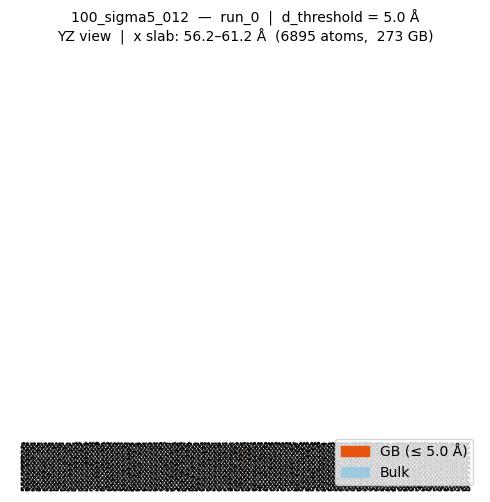

In [ ]:
# ── Figure 1: YZ view — thin x-slab to avoid overplotting ───────────────────
BULK_COLOR = "#9ecae1"   # light blue
GB_COLOR   = "#e6550d"   # orange-red

colors = np.where(mask, GB_COLOR, BULK_COLOR)

# Keep only atoms in the front SLAB_THICKNESS Å of x — gives a clean cross-section
# without losing any information about the GB structure (GB planes are z-aligned)
pos = atoms.get_positions()
x_max = pos[:, 0].max()
slab_idx = np.where(pos[:, 0] >= x_max - SLAB_THICKNESS)[0]

slab_atoms  = atoms[slab_idx]
slab_colors = colors[slab_idx]
n_slab_gb   = mask[slab_idx].sum()

fig, ax = plt.subplots(figsize=(5, 9))
fig.suptitle(
    f"{GB_LABEL}  —  run_{run_idx}  |  d_threshold = {D_THRESHOLD} Å"
    f"\nYZ view  |  x slab: {x_max - SLAB_THICKNESS:.1f}–{x_max:.1f} Å"
    f"  ({len(slab_idx)} atoms,  {n_slab_gb} GB)",
    fontsize=10,
)
plot_atoms(slab_atoms, ax, colors=slab_colors, rotation="0x,90y,0z", radii=0.4)
ax.axis("off")

legend = [
    mpatches.Patch(color=GB_COLOR,   label=f"GB (≤ {D_THRESHOLD} Å)"),
    mpatches.Patch(color=BULK_COLOR, label="Bulk"),
]
ax.legend(handles=legend, loc="lower right", fontsize=10, frameon=True)
plt.tight_layout()
plt.show()
# TODO: make this somehow plot-able, this is still too difficult to see what's going on

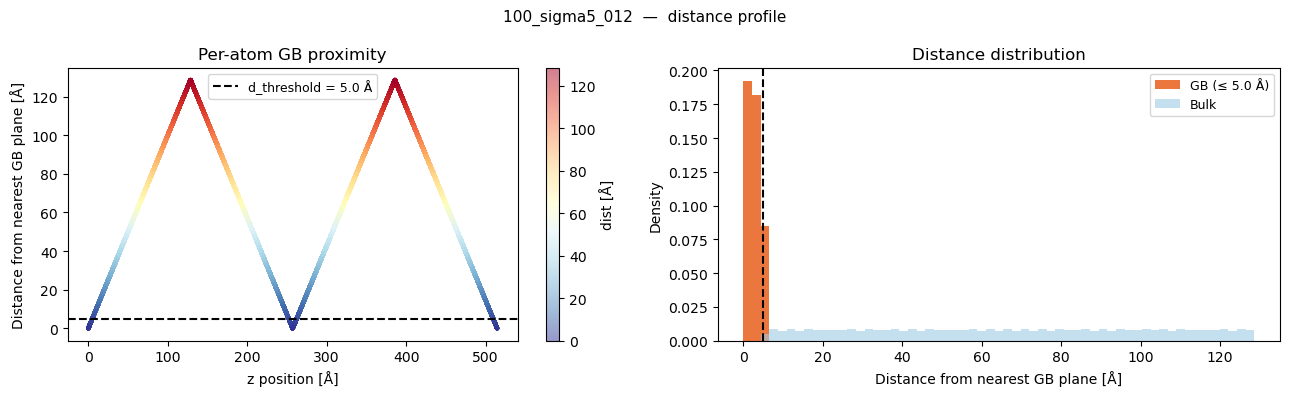

In [6]:
# ── Figure 2: distance-from-GB-plane profile ──────────────────────────────────
# Shows every atom's z-position coloured by its distance from the nearest GB plane.
# The horizontal band marks the threshold — atoms inside it should match Figure 1.

scaled_z_plot = atoms.get_scaled_positions()[:, 2] % 1.0
z_ang = scaled_z_plot * cell_len   # absolute z position in Å

# Colour by continuous distance for the scatter
cmap   = plt.cm.RdYlBu_r
vmax   = cell_len * 0.25   # half-grain thickness
c_vals = np.clip(dist_ang, 0, vmax)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: scatter of z position vs distance, threshold band shaded
sc = axes[0].scatter(
    z_ang, dist_ang,
    c=c_vals, cmap=cmap, vmin=0, vmax=vmax,
    s=4, alpha=0.5, rasterized=True,
)
axes[0].axhline(D_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
                label=f"d_threshold = {D_THRESHOLD} Å")
axes[0].set_xlabel("z position [Å]")
axes[0].set_ylabel("Distance from nearest GB plane [Å]")
axes[0].set_title("Per-atom GB proximity")
axes[0].legend(fontsize=9)
plt.colorbar(sc, ax=axes[0], label="dist [Å]")

# Right: histogram of distances — GB vs bulk split
bins = np.linspace(0, cell_len * 0.25, 60)
axes[1].hist(dist_ang[mask],  bins=bins, color=GB_COLOR,   alpha=0.8,
             label=f"GB (≤ {D_THRESHOLD} Å)", density=True)
axes[1].hist(dist_ang[~mask], bins=bins, color=BULK_COLOR, alpha=0.6,
             label="Bulk", density=True)
axes[1].axvline(D_THRESHOLD, color="black", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Distance from nearest GB plane [Å]")
axes[1].set_ylabel("Density")
axes[1].set_title("Distance distribution")
axes[1].legend(fontsize=9)

fig.suptitle(f"{GB_LABEL}  —  distance profile", fontsize=11)
plt.tight_layout()
plt.show()

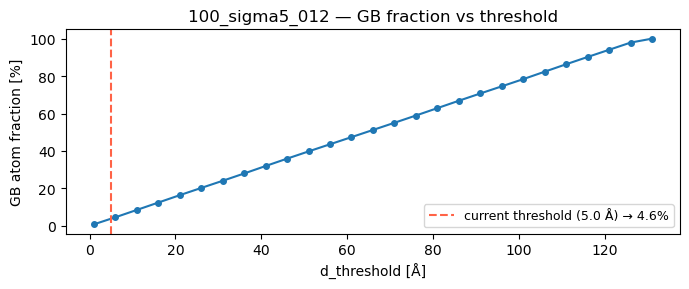

In [7]:
# ── Figure 3: sweep over multiple thresholds ─────────────────────────────────
# Quick sanity-check: how does the GB atom fraction change with d_threshold?

thresholds = np.arange(1.0, cell_len * 0.26, 5)
fractions  = [identify_gb_atoms(atoms, d).sum() / len(atoms) * 100 for d in thresholds]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(thresholds, fractions, marker="o", markersize=4, linewidth=1.5)
ax.axvline(D_THRESHOLD, color="tomato", linestyle="--", linewidth=1.5,
           label=f"current threshold ({D_THRESHOLD} Å) → {fractions[np.argmin(np.abs(thresholds - D_THRESHOLD))]:.1f}%")
ax.set_xlabel("d_threshold [Å]")
ax.set_ylabel("GB atom fraction [%]")
ax.set_title(f"{GB_LABEL} — GB fraction vs threshold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()